# Perform 2-protein mass tethering analysis
If a protein is in a complex or as a PTM, it can show up as 2 different masses. This notebook analyses both masses at the same time to give a comprehensive picture of labeling. Caveats: there can be collisions between your protein masses and expected adducts / caps. 
- https://pubmed.ncbi.nlm.nih.gov/28945980/
- match PLP pipeline
- extend to multiple labeling
- visualize plate maps and %BPI curves
- depending on system, this analysis is ~10x faster than pipeline pilot

In [46]:
import os
import pandas as pd
import numpy as np
import logging
import sys
sys.path.append('/Users/apaulson/repos/data-proc')
import plate_maps as pm
sys.path.append('/Users/apaulson/repos/smdc_process_data/process_data')
import tethering_analysis as ta

%config Completer.use_jedi=False
logging.basicConfig(level=logging.INFO)
import importlib
importlib.reload(ta)

<module 'tethering_analysis' from '/Users/apaulson/repos/smdc_process_data/process_data/tethering_analysis.py'>

In [47]:
barcodes=[
"SMDC-MPHORE-384-1-02-Eco1",
"SMDC-MPHORE-384-2-02-Eco1",
"SMDC-MPHORE-384-3-02-Eco1",
"SMDC-MPHORE-384-4-02-Eco1",
"SMDC-MPHORE-384-5-02-Eco1",
"SMDC-MPHORE-384-6-01-Eco1",
"SMDC-MPHORE-384-7-01-Eco1",
"SMDC-MPHORE-384-8-02-Eco1"
]
barcodes=['TAZ_P91','TAZ_P93']

In [48]:
for barcode in barcodes:
    # # DATA INPUT # #
    # # --------------------------------------- # #
    HA_ID=2669
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    # barcode=barcodes[1]
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    pmirm=False # protein mass is reacted mass
    cmirm=True # cap mass is reacted mass
    rmirm=True # reductant mass is reacted mass
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    scan_range = 10
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    assay_class='HTS'
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    # masses=[65036, 65215]
    masses=None # for single mass analysis, set to None to use default mass from database
    if masses is None:
        mass2=""
    else:
        mass2="_2masses"
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    infile=f"../data/{barcode}.rpt"
    # # --------------------------------------- # #
    # # --------------------------------------- # #
    outdir=f"./{HA_ID}_tethering_analysis{mass2}"
    # # --------------------------------------- # #


    df=ta.extract_rpt_data(infile, outdir=outdir)
    addcaps, masses, site_count=ta.calculate_adduct_and_cap_ranges(HA_ID, barcode, pmirm=pmirm, cmirm=cmirm, rmirm=rmirm, scan_range=scan_range, masses=masses)
    df=ta.analyze_rpt_data(df, addcaps, masses, site_count, scan_range, outdir=outdir)

    dfm=ta.prepare_for_plotting(df, addcaps, barcode)
    dfm=dfm.sort_values(['Row','Col',])
    dfm.to_csv(os.path.join(outdir, f'{barcode}{mass2}_raw_data.csv'))

    map=pm.draw_plate_heatmap(barcode=barcode, df=dfm[dfm.protein_mass==masses[0]], wells='Well', values='percentlabeled', labels='hmlab', 
                              center=None, vmin=None, vmax=None, width=25, outdir=os.path.join(outdir, 'heatmaps'))

    # # plot all BPI spectra for each SMDC ID (per plate)
    # for smdc in dfm.SMDC_ID.unique():
    #     if smdc is np.nan:
    #         continue
    #     ta.plot_bpi(dfm, smdc, scan_range, outdir=outdir)



 ../data/TAZ_P91.rpt


INFO:root:Adduct mass is not defined for 80 rows.
INFO:root:Analyzing data for 320 samples.




 ../data/TAZ_P93.rpt


INFO:root:Adduct mass is not defined for 80 rows.
INFO:root:Analyzing data for 320 samples.


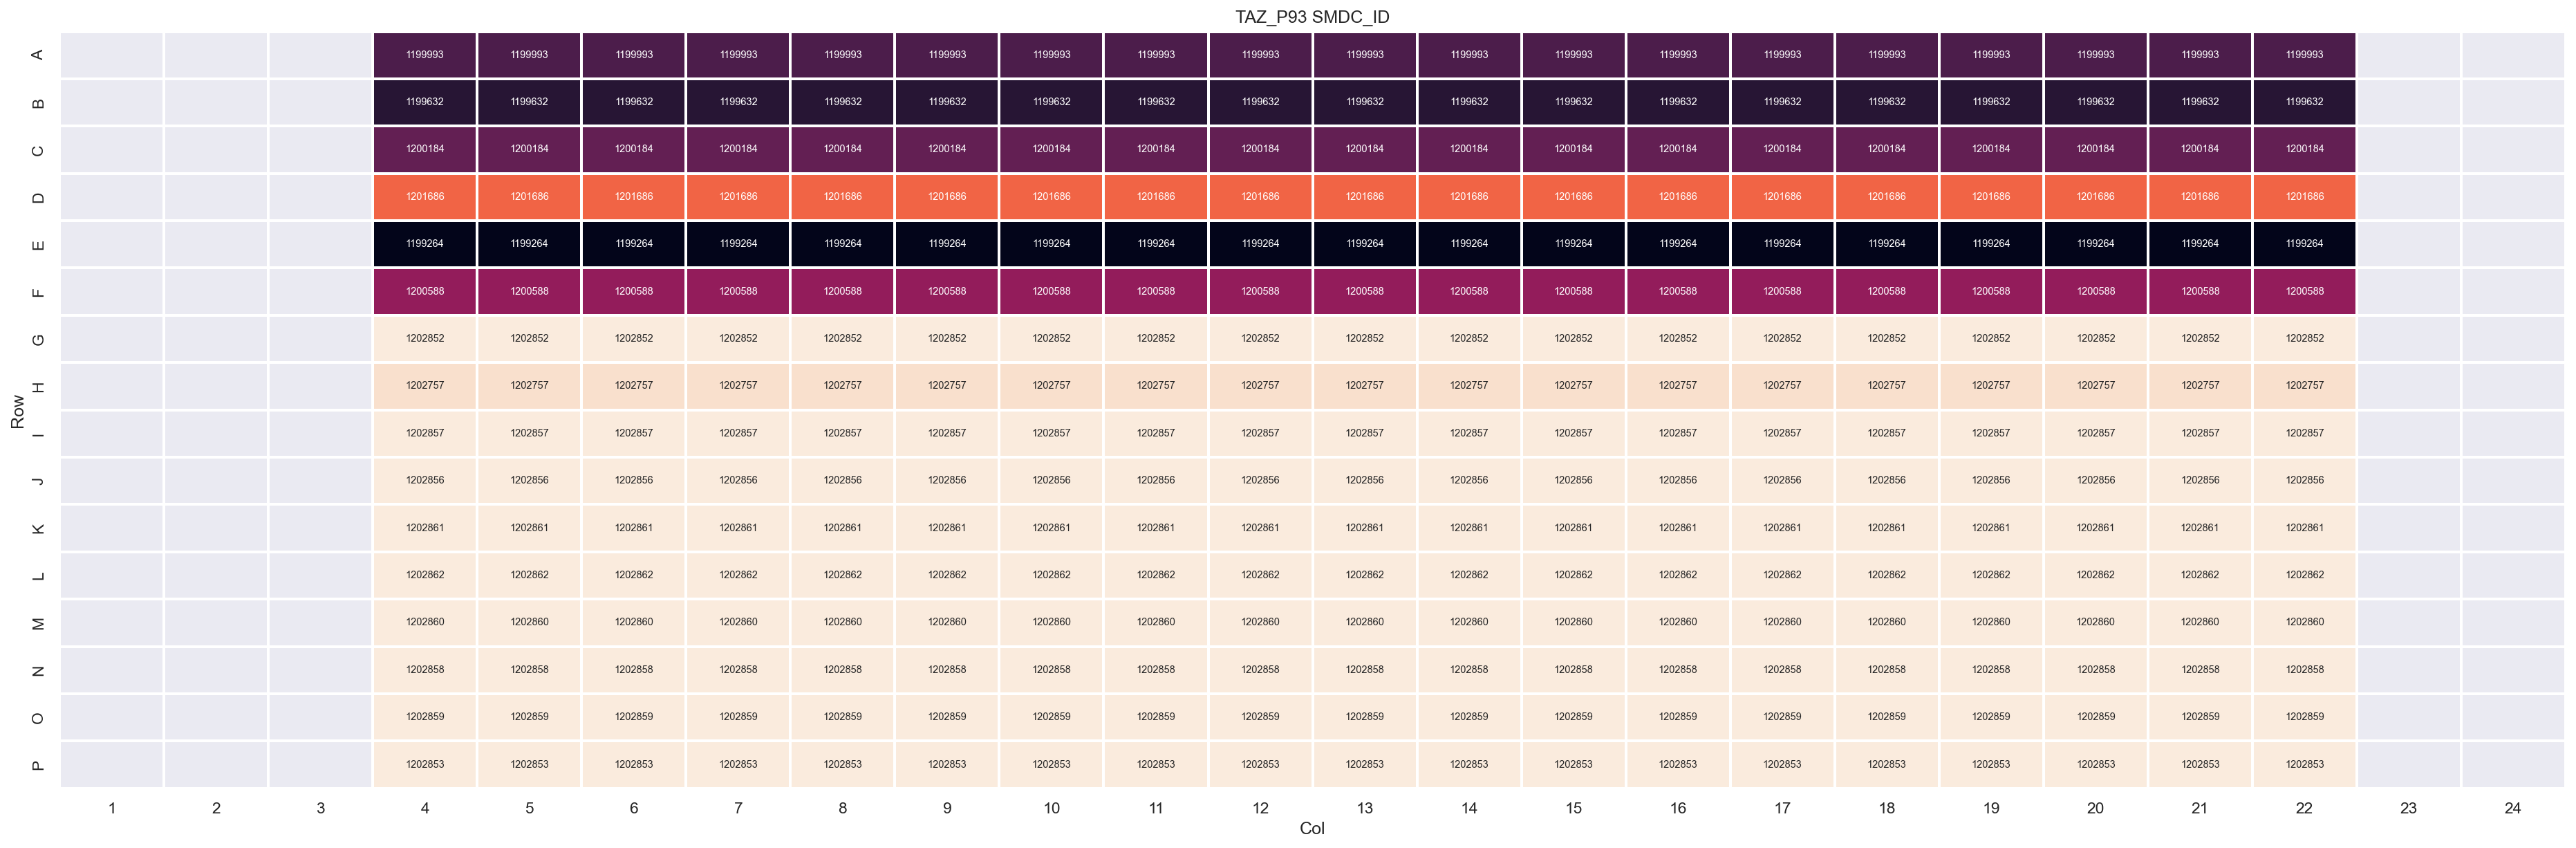

In [49]:
map=pm.draw_plate_heatmap(barcode=barcode)

In [50]:
importlib.reload(ta)
# %debug
smdc=dfm[dfm.Well=='H10'].SMDC_ID.iloc[0]
smdcs=[smdc]
print(smdcs)

[1202757.0]


In [52]:
# plot all
importlib.reload(ta)
for smdc in smdcs:
  ta.plot_bpi(dfm, smdc, scan_range, outdir=outdir)

In [53]:
for smdc in smdcs:
    ta.make_gif_filtered(os.path.join(outdir, 'trace_images'), substring=str(int(smdc)), outdir=outdir, trace='mult')

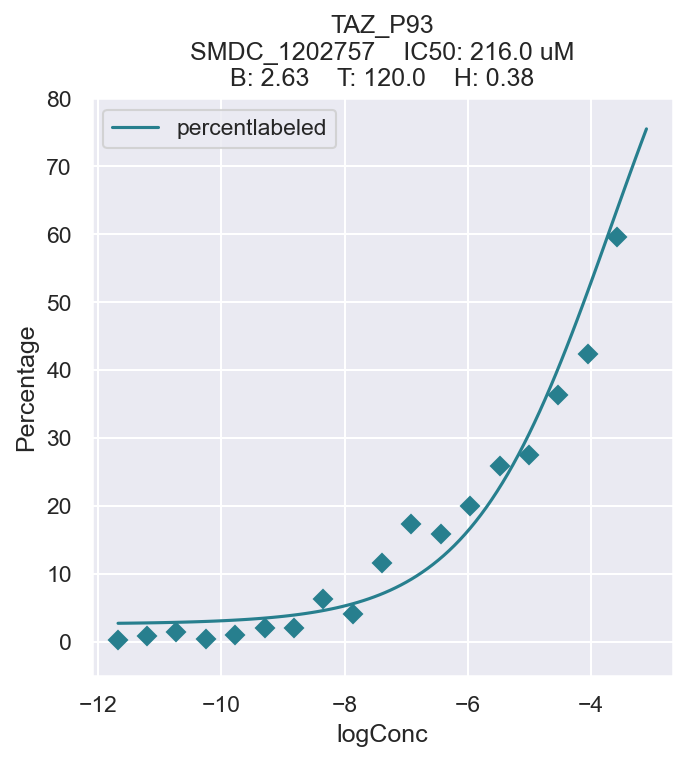

In [54]:
for smdc in smdcs:
    ta.plot_dr_curve(dfm, smdc, outdir=outdir, save=False)